In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
from scipy.stats import bootstrap
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 16

In [2]:
DP = DP()
all_df, _, _, _ = DP.extract_fits_data('./catalogs/0428_all_test.fits')
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0428_dps_test.fits')

In [3]:
print(len(all_df))
print(len(dps_df))

57271
21178


In [4]:
dps_df.head(10)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.274399,-78.119492,48.701080,29.865618,...,-1.000000,-1.000000,-1.000000,256,256,256,512,0.227097,-0.661874,1
1,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,78.897018,-91.391823,57.324131,58.142452,...,3.985946,-1.000000,-1.000000,256,256,256,512,-0.173369,-1.161603,2
2,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.714844,-73.869621,38.259602,50.303757,...,15.984617,7.496104,4.716895,1,1,1,2,0.114889,0.235638,7
3,39627739384252917,177.358017,-1.933391,0.082934,10.019835,-1.504955,63.157669,-32.048058,18.166857,88.177879,...,6.727219,-1.000000,-1.000000,4,4,1,5,-0.897420,-1.292883,1
4,39627739384253125,177.367218,-1.890628,0.082792,9.603887,0.054528,33.326653,-35.945473,38.321335,31.474480,...,24.676777,12.838582,8.797763,1,1,1,2,-0.016886,0.147740,9
5,39627739384253866,177.401154,-1.923410,0.322626,10.556721,1.160900,75.359352,-83.432549,62.639046,50.840076,...,5.290285,-1.000000,-1.000000,256,256,256,512,0.405406,-0.517615,2
6,39627739384254171,177.415359,-1.963895,0.242680,10.280345,0.504521,114.831711,-22.619661,12.339811,82.171326,...,4.464350,-1.000000,-1.000000,256,256,256,512,-0.730360,-0.960908,1
7,39627739384254755,177.441299,-1.894929,0.323152,10.681046,0.655952,93.642540,-88.703712,66.629433,82.264191,...,10.454165,3.994982,3.334108,256,256,256,512,0.996128,0.118755,4
8,39627739388450085,177.708908,-1.988507,0.174826,10.169887,0.802034,89.958336,-39.593479,32.181519,54.862911,...,19.103786,8.636097,5.648437,4,4,1,5,0.479024,0.431293,8
9,39627739392641040,177.827560,-1.906158,0.238993,10.448782,1.357372,94.510727,-87.162048,98.305153,70.173584,...,4.700925,-1.000000,-1.000000,256,256,256,512,0.034530,-0.823302,2


In [5]:
#  & (all_df['BPT_1COMP']!=16)& (all_df['BPT_1COMP']!=64)
all_df = all_df[((~all_df['LOGSFR_1COMP'].isna())|(all_df['LOGSFR_1COMP']!=np.inf)) & (all_df['LOGM']!=0) & (all_df['Halpha_SNR']>0) & (all_df['Halpha_SNR']>all_df['OIII5007_SNR'])]
dps_df = dps_df[((~dps_df['LOGSFR_2COMP'].isna())|(dps_df['LOGSFR_2COMP']!=np.inf)) & (dps_df['LOGM']!=0) & (dps_df['Halpha_SNR']>0) & (dps_df['Halpha_SNR']>dps_df['OIII5007_SNR'])]
cs_df  = all_df[~all_df['TARGETID'].isin(dps_df['TARGETID'])]

In [6]:
all_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,Halpha_SNR,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP
0,39627739380056197,177.003815,-1.903397,0.224113,10.250154,-0.348563,59.528633,-13.745420,0.001000,60.800022,...,6.431108,-1.000000,-1.000000,-1.00000,256,256,256,512,-1.404834,-1.510605
1,39627739380056420,177.013474,-1.972766,0.102005,9.722919,-0.349153,45.080700,-22.300671,0.013366,39.671345,...,6.388631,-1.000000,-1.000000,-1.00000,256,256,256,512,-1.475483,-2.224608
2,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.274399,-78.119492,48.701080,29.865618,...,7.858130,-1.000000,-1.000000,-1.00000,256,256,256,512,0.227097,-0.661874
3,39627739380056768,177.028137,-1.960056,0.102814,10.143390,0.193251,3.404383,-128.566391,44.083996,0.001000,...,25.210096,5.762295,6.139219,4.72956,1,1,1,2,-0.371622,-0.372998
4,39627739380056864,177.032974,-1.909970,0.167324,10.575974,-9.632146,28.085899,-80.672951,93.631432,117.731117,...,4.319530,3.153928,-1.000000,-1.00000,256,256,256,512,-1.300670,-2.063501


In [7]:
print(len(all_df))
print(len(dps_df))
print(len(cs_df))

51290
20765
30525


In [8]:
x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

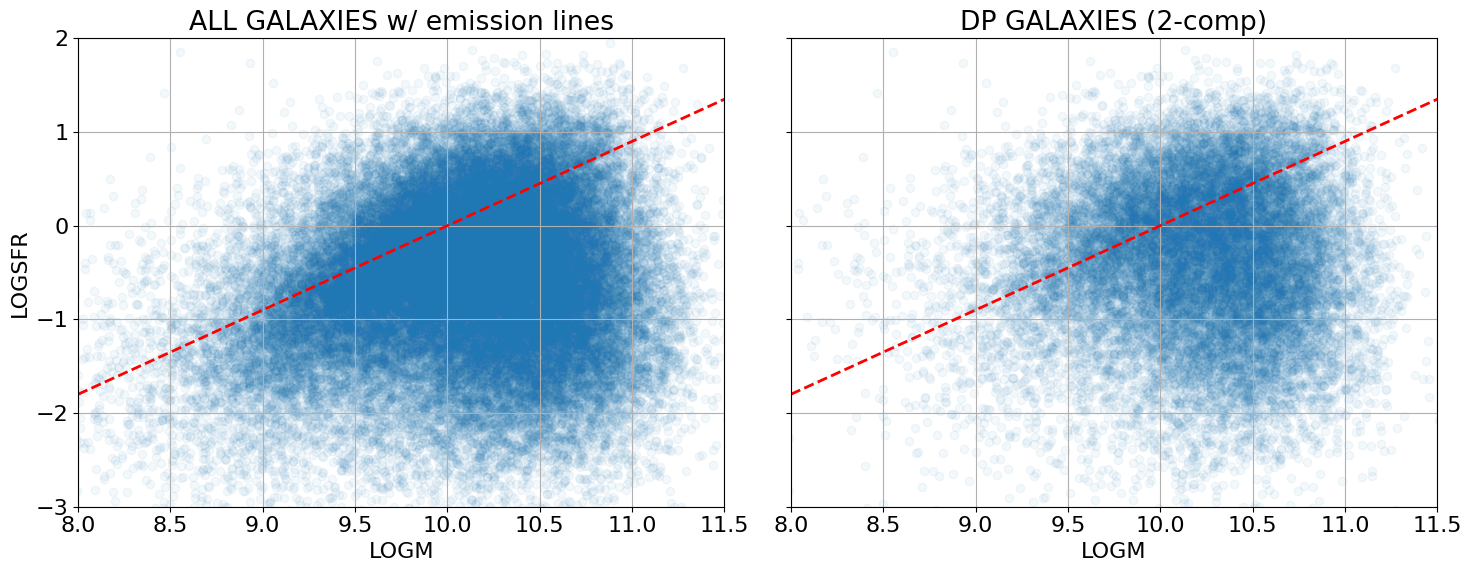

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0)


ax[0].scatter(dps_df['LOGM'], dps_df['LOGSFR_2COMP'], alpha=0.05, color='C0')
ax[0].scatter(cs_df['LOGM'], cs_df['LOGSFR_1COMP'], alpha=0.05, color='C0')
ax[0].plot(x, y, color='red', linestyle='--', linewidth=2)
ax[0].set_ylim((-3, 2))
ax[0].set_xlim((8, 11.5))
ax[0].set_xlabel('LOGM')
ax[0].set_ylabel('LOGSFR')
ax[0].set_title('ALL GALAXIES w/ emission lines')
ax[0].grid()

ax[1].scatter(dps_df['LOGM'], dps_df['LOGSFR_2COMP'], alpha=0.05)
ax[1].plot(x, y, color='red', linestyle='--', linewidth=2)
ax[1].set_ylim((-3, 2))
ax[1].set_xlim((8, 11.5))
ax[1].set_xlabel('LOGM')
ax[1].set_title('DP GALAXIES (2-comp)')
ax[1].grid()
plt.tight_layout()
# plt.savefig('./figures/progress_apr/M_SFR_bin.png')
plt.show()

In [10]:
distance = cosmo.luminosity_distance(dps_df['Z'].values).to(u.cm).value
dps_df['Halpha_LUM'] = 4 * np.pi * (distance)**2 * (dps_df['Halpha_FLUX_2COMP_R']+dps_df['Halpha_FLUX_2COMP_L'])
dps_df['OII_LUM'] = 4 * np.pi * (distance)**2 * (dps_df['OII3729_FLUX_2COMP_R']+dps_df['OII3729_FLUX_2COMP_L'])



distance = cosmo.luminosity_distance(cs_df['Z'].values).to(u.cm).value
cs_df['Halpha_LUM'] = 4 * np.pi * (distance)**2 * (cs_df['Halpha_FLUX_1COMP'])
cs_df['OII_LUM'] = 4 * np.pi * (distance)**2 * (cs_df['OII3729_FLUX_1COMP'])


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_1977/984486359.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cs_df['Halpha_LUM'] = 4 * np.pi * (distance)**2 * (cs_df['Halpha_FLUX_1COMP'])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_1977/984486359.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cs_df['OII_LUM'] = 4 * np.pi * (distance)**2 * (cs_df['OII3729_FLUX_1COMP'])


In [11]:
cs_df['LOGSFR'] = cs_df['LOGSFR_1COMP']
dps_df['LOGSFR'] = dps_df['LOGSFR_2COMP']
real_all_df = pd.concat([cs_df, dps_df])

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_1977/3508055859.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cs_df['LOGSFR'] = cs_df['LOGSFR_1COMP']


In [12]:
real_all_no_agn = real_all_df[~real_all_df['BPT_1COMP'].isin([16, 64])].copy()
dps_df_no_agn = dps_df[~dps_df['BPT_1COMP'].isin([16, 64])].copy()

real_all_agn = real_all_df[real_all_df['BPT_1COMP'].isin([16, 64])].copy()
dps_df_agn = dps_df[dps_df['BPT_1COMP'].isin([16, 64])].copy()

In [13]:
logm_bins_bound = np.arange(8, 12, 0.25)
logsfr_bins_bound = np.arange(-3, 2, 1/3)
logHalpha_bins_bound = np.arange(37.5, 43.0, 1)
logOII_bins_bound = np.linspace(38.5, 42.5, 8)
snr_bins_bound = np.logspace(np.log10(3), np.log10(300), 20)
logssfr_bins_bound = np.arange(-14, -8, 0.5)

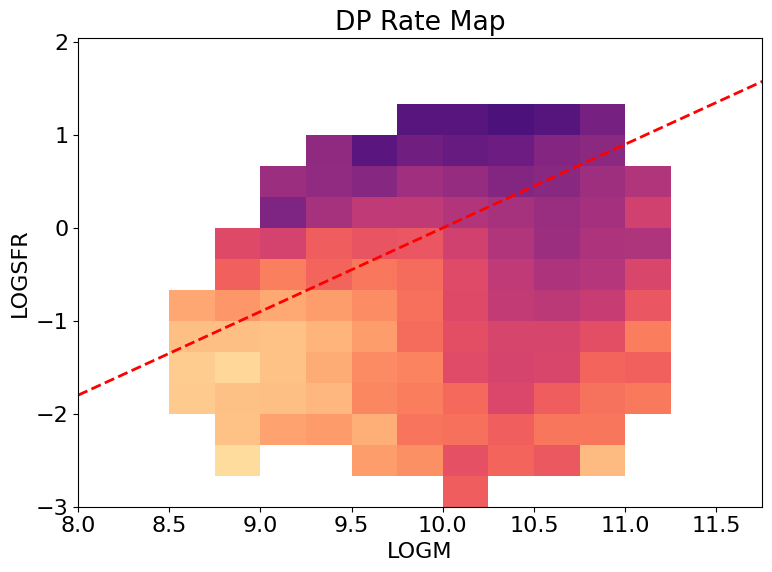

In [14]:
H_all, _, _ = np.histogram2d(real_all_no_agn['LOGM'], real_all_no_agn['LOGSFR'], bins=[logm_bins_bound, logsfr_bins_bound])
H_dps, _, _ = np.histogram2d(dps_df_no_agn['LOGM'], dps_df_no_agn['LOGSFR'], bins=[logm_bins_bound, logsfr_bins_bound])

# Avoid division by zero by replacing zeros in H_all with NaNs
with np.errstate(divide='ignore', invalid='ignore'):
    dp_rate_map = np.where(H_all<50, np.nan, H_dps / H_all)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(x, y, color='red', linestyle='--', linewidth=2)
# Use pcolormesh to plot the DP rate map
# Note: The histogram arrays need to be transposed for pcolormesh to match the axes
mesh = ax.pcolormesh(logm_bins_bound, logsfr_bins_bound, dp_rate_map.T, cmap='magma_r', vmin=0, vmax=1)

# Add text annotations for the rate in each bin
# for i in range(len(logm_bins_bound) - 1):
#     for j in range(len(logsfr_bins_bound) - 1):
#         rate = dp_rate_map[i, j]
#         if not np.isnan(rate):
#             x_center = (logm_bins_bound[i] + logm_bins_bound[i+1]) / 2
#             y_center = (logsfr_bins_bound[j] + logsfr_bins_bound[j+1]) / 2
#             ax.text(x_center, y_center, f'{rate:.2f}', 
#                     ha='center', va='center', color='white', fontsize=12)

ax.set_xlabel('LOGM')
ax.set_ylabel('LOGSFR')
ax.set_title('DP Rate Map')
ax.set_xlim(logm_bins_bound[0], logm_bins_bound[-1])
# fig.colorbar(mesh, ax=ax, label='DP Rate')
plt.tight_layout()
# plt.savefig('./figures/Apr30/DP_rate_map.png')
plt.show()

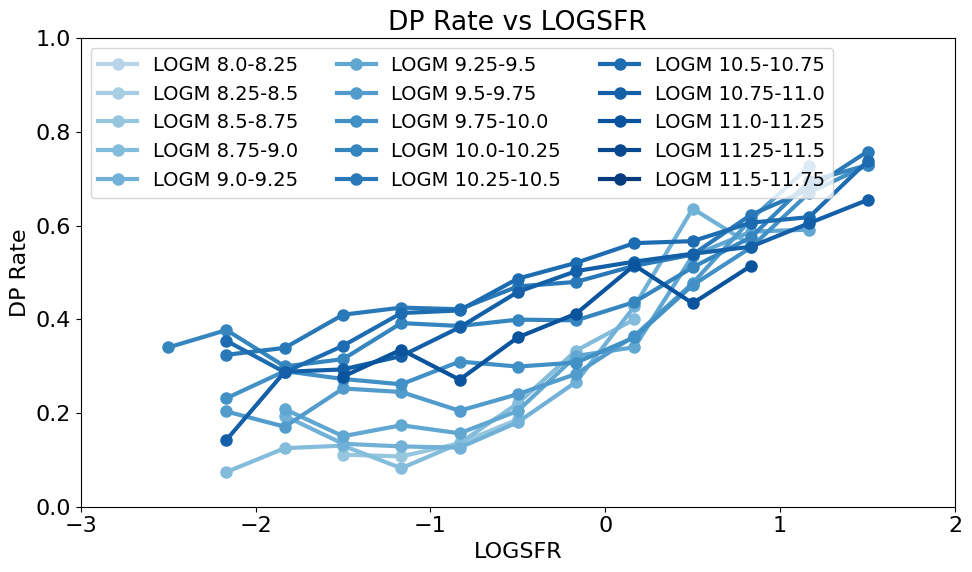

In [15]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.3, 1, len(logm_bins_bound)))
for i in range(len(logm_bins_bound) - 1):
    plt.plot(logsfr_bins_bound[:-1]+0.5, dp_rate_map[i, :], label=f'LOGM {logm_bins_bound[i]}-{logm_bins_bound[i+1]}', marker='o', color=colors[i], linewidth=3, markersize=8)
plt.xlim(-3, 2)
plt.ylim(0, 1)
plt.xlabel('LOGSFR')
plt.ylabel('DP Rate')
plt.title('DP Rate vs LOGSFR')
plt.legend(fontsize=14, ncol=3, loc='upper left')
plt.tight_layout()
plt.savefig('./figures/Apr30/DP_rate_vs_logsfr.png')
plt.show()

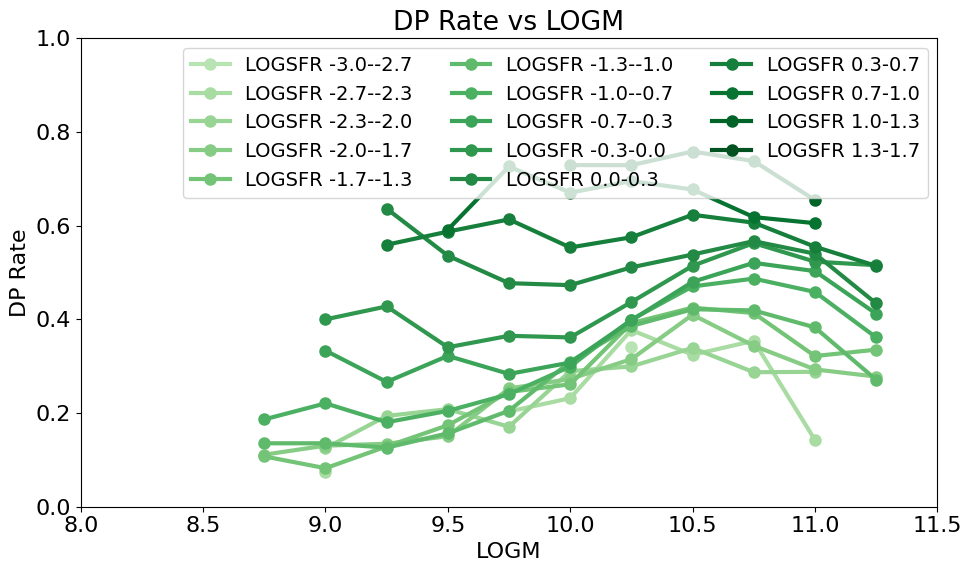

In [16]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Greens(np.linspace(0.3, 1, len(logsfr_bins_bound)))
for i in range(len(logsfr_bins_bound) - 1):
    plt.plot(logm_bins_bound[:-1]+0.25, dp_rate_map[:, i], label=f'LOGSFR {logsfr_bins_bound[i]:.1f}-{logsfr_bins_bound[i+1]:.1f}', marker='o', color=colors[i], linewidth=3, markersize=8)
plt.xlim(8, 11.5)
plt.ylim(0, 1)
plt.xlabel('LOGM')
plt.ylabel('DP Rate')
plt.title('DP Rate vs LOGM')
plt.legend(fontsize=14, ncol=3)
plt.tight_layout()
plt.savefig('./figures/Apr30/DP_rate_vs_logm.png')
plt.show()

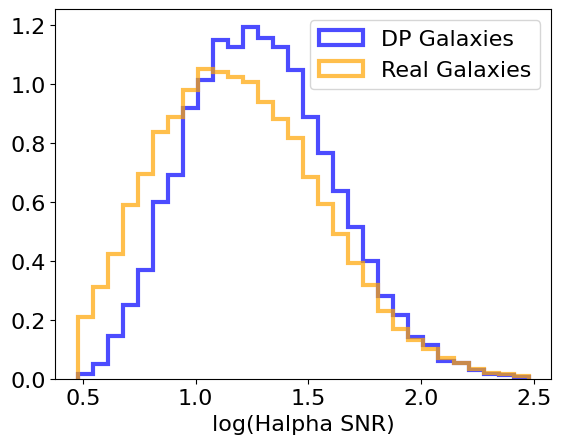

In [17]:
plt.hist(np.log10(dps_df_no_agn['Halpha_SNR']), bins=30, histtype='step', linewidth=3, color='blue', alpha=0.7, density=True, label='DP Galaxies', range=(np.log10(3), np.log10(300)))
plt.hist(np.log10(real_all_no_agn['Halpha_SNR']), bins=30, histtype='step', linewidth=3, color='orange', alpha=0.7, density=True, label='Real Galaxies', range=(np.log10(3), np.log10(300)))
plt.xlabel('log(Halpha SNR)')
# plt.xlim(0, 150)
plt.legend()
plt.show()

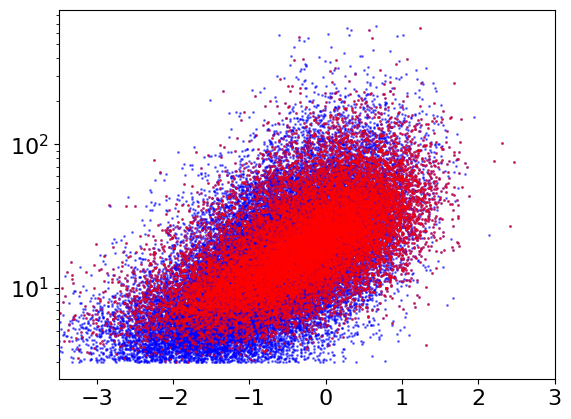

In [18]:
plt.scatter(real_all_no_agn['LOGSFR'], real_all_no_agn['Halpha_SNR'], c='blue', label='All Galaxies', alpha=0.5, s=1)
plt.scatter(dps_df_no_agn['LOGSFR'], dps_df_no_agn['Halpha_SNR'], c='red', label='DP Galaxies', alpha=0.5, s=1)
plt.yscale('log')
plt.xlim(-3.5, 3)
plt.show()

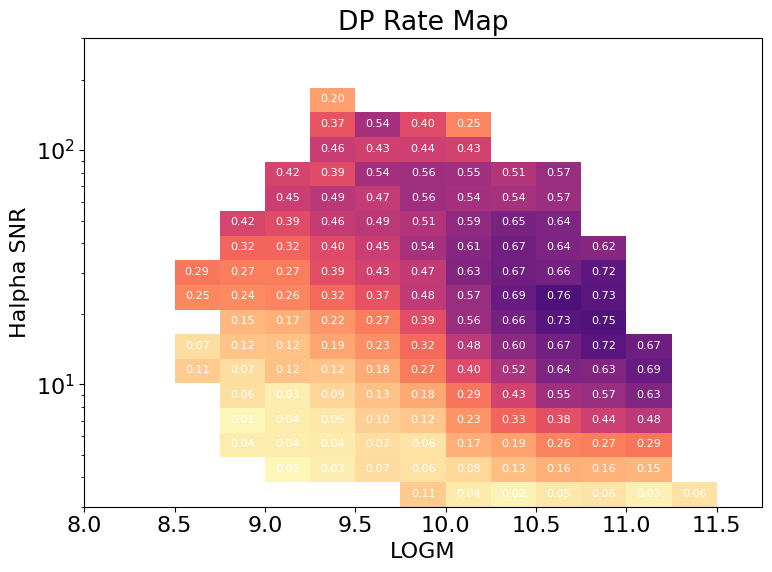

In [19]:
H_all, _, _ = np.histogram2d(real_all_no_agn['LOGM'], (real_all_no_agn['Halpha_SNR']), bins=[logm_bins_bound, snr_bins_bound])
H_dps, _, _ = np.histogram2d(dps_df_no_agn['LOGM'], (dps_df_no_agn['Halpha_SNR']), bins=[logm_bins_bound, snr_bins_bound])

# Avoid division by zero by replacing zeros in H_all with NaNs
with np.errstate(divide='ignore', invalid='ignore'):
    dp_rate_map = np.where(H_all<50, np.nan, H_dps / H_all)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# Use pcolormesh to plot the DP rate map
# Note: The histogram arrays need to be transposed for pcolormesh to match the axes
mesh = ax.pcolormesh(logm_bins_bound, snr_bins_bound, dp_rate_map.T, cmap='magma_r', vmin=0, vmax=1)

# Add text annotations for the rate in each bin
for i in range(len(logm_bins_bound) - 1):
    for j in range(len(snr_bins_bound) - 1):
        rate = dp_rate_map[i, j]
        if not np.isnan(rate):
            x_center = (logm_bins_bound[i] + logm_bins_bound[i+1]) / 2
            y_center = (snr_bins_bound[j] + snr_bins_bound[j+1]) / 2
            ax.text(x_center, y_center, f'{rate:.2f}', 
                    ha='center', va='center', color='white', fontsize=8)

ax.set_xlabel('LOGM')
ax.set_ylabel('Halpha SNR')
ax.set_title('DP Rate Map')
ax.set_xlim(logm_bins_bound[0], logm_bins_bound[-1])
ax.set_ylim(snr_bins_bound[0], snr_bins_bound[-1])
ax.set_yscale('log')
# fig.colorbar(mesh, ax=ax, label='DP Rate')
plt.tight_layout()
plt.show()

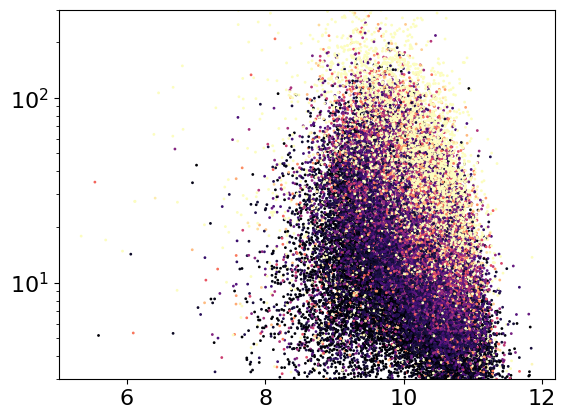

In [32]:
plt.scatter(real_all_no_agn['LOGM'], (real_all_no_agn['Halpha_SNR']), c=np.log10(real_all_no_agn['P_VALUE']), cmap='magma_r', s=1)
plt.yscale('log')
plt.ylim(3,300)
plt.show()

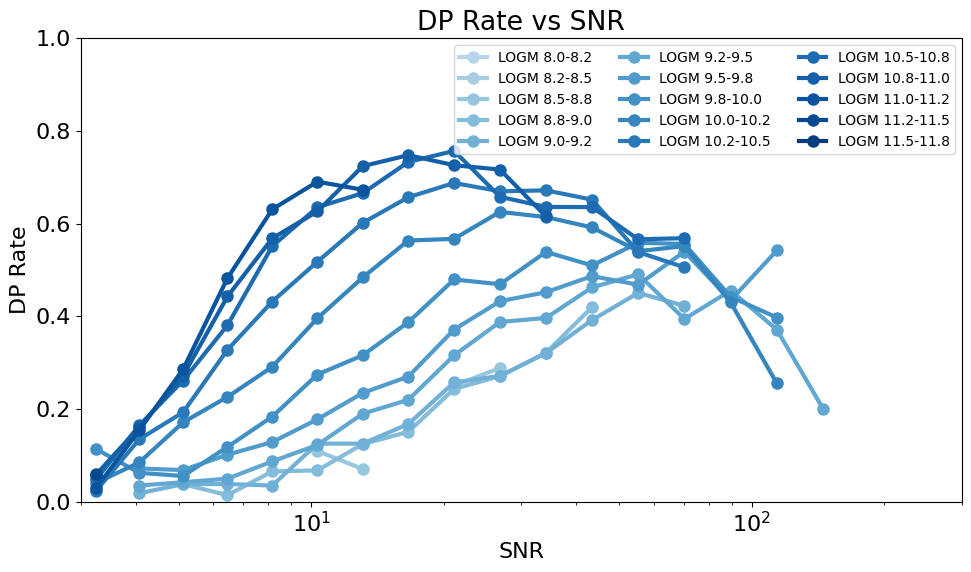

In [20]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.3, 1, len(logm_bins_bound)))
for i in range(len(logm_bins_bound) - 1):
    plt.plot(snr_bins_bound[:-1]+0.25, dp_rate_map[i, :], label=f'LOGM {logm_bins_bound[i]:.1f}-{logm_bins_bound[i+1]:.1f}', marker='o', color=colors[i], linewidth=3, markersize=8)
# plt.axvline(x=10, color='red', linestyle='--', linewidth=3)
plt.xlim(3, 300)
plt.xscale('log')
plt.ylim(0, 1)
plt.xlabel('SNR')
plt.ylabel('DP Rate')
plt.title('DP Rate vs SNR')
plt.legend(fontsize=10, ncol=3)
plt.tight_layout()
# plt.savefig('./figures/Apr30/DP_rate_vs_logm.png')
plt.show()

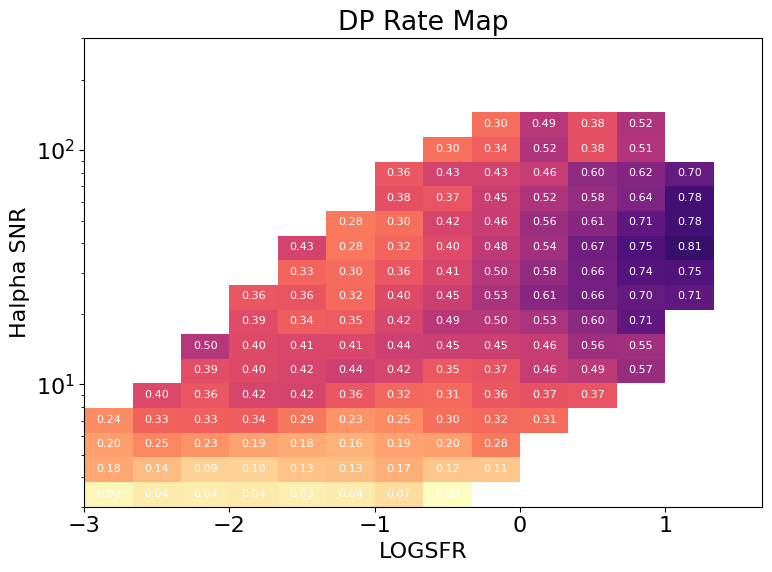

In [21]:
H_all, _, _ = np.histogram2d(real_all_no_agn['LOGSFR'], (real_all_no_agn['Halpha_SNR']), bins=[logsfr_bins_bound, snr_bins_bound])
H_dps, _, _ = np.histogram2d(dps_df_no_agn['LOGSFR'], (dps_df_no_agn['Halpha_SNR']), bins=[logsfr_bins_bound, snr_bins_bound])

# Avoid division by zero by replacing zeros in H_all with NaNs
with np.errstate(divide='ignore', invalid='ignore'):
    dp_rate_map = np.where(H_all<50, np.nan, H_dps / H_all)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# Use pcolormesh to plot the DP rate map
# Note: The histogram arrays need to be transposed for pcolormesh to match the axes
mesh = ax.pcolormesh(logsfr_bins_bound, snr_bins_bound, dp_rate_map.T, cmap='magma_r', vmin=0, vmax=1)

# Add text annotations for the rate in each bin
for i in range(len(logsfr_bins_bound) - 1):
    for j in range(len(snr_bins_bound) - 1):
        rate = dp_rate_map[i, j]
        if not np.isnan(rate):
            x_center = (logsfr_bins_bound[i] + logsfr_bins_bound[i+1]) / 2
            y_center = (snr_bins_bound[j] + snr_bins_bound[j+1]) / 2
            ax.text(x_center, y_center, f'{rate:.2f}', 
                    ha='center', va='center', color='white', fontsize=8)

ax.set_xlabel('LOGSFR')
ax.set_ylabel('Halpha SNR')
ax.set_title('DP Rate Map')
ax.set_xlim(logsfr_bins_bound[0], logsfr_bins_bound[-1])
ax.set_ylim(snr_bins_bound[0], snr_bins_bound[-1])
ax.set_yscale('log')
# fig.colorbar(mesh, ax=ax, label='DP Rate')
plt.tight_layout()
plt.show()

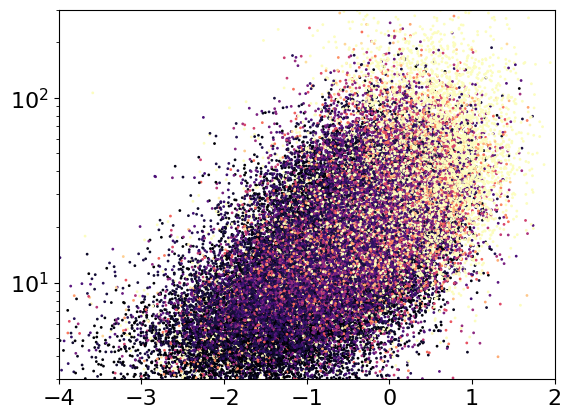

In [ ]:
plt.scatter(real_all_no_agn['LOGSFR'], (real_all_no_agn['Halpha_SNR']), c=np.log10(real_all_no_agn['P_VALUE']), cmap='magma_r', s=1)
plt.yscale('log')
plt.ylim(3,300)
plt.xlim(-4, 2)
plt.show()

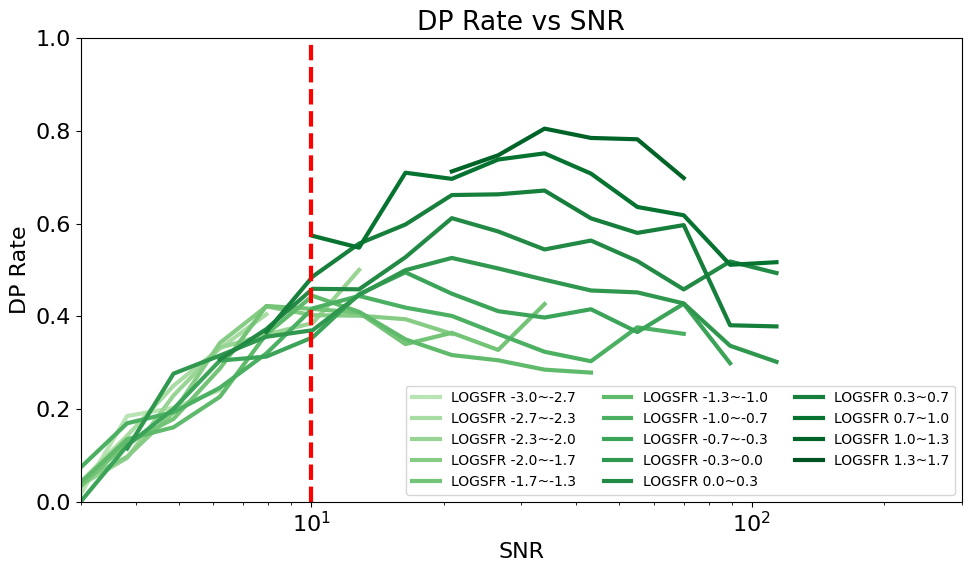

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Greens(np.linspace(0.3, 1, len(logsfr_bins_bound)))
for i in range(len(logsfr_bins_bound) - 1):
    plt.plot(snr_bins_bound[:-1], dp_rate_map[i, :], label=f'LOGSFR {logsfr_bins_bound[i]:.1f}~{logsfr_bins_bound[i+1]:.1f}', color=colors[i], linewidth=3, marker='o', markersize=8)
plt.axvline(x=10, color='red', linestyle='--', linewidth=3)
plt.xlim(3, 300)
plt.xscale('log')
plt.ylim(0, 1)
plt.xlabel('SNR')
plt.ylabel('DP Rate')
plt.title('DP Rate vs SNR')
plt.legend(fontsize=10, ncol=3)
plt.tight_layout()
# plt.savefig('./figures/Apr30/DP_rate_vs_logm.png')
plt.show()

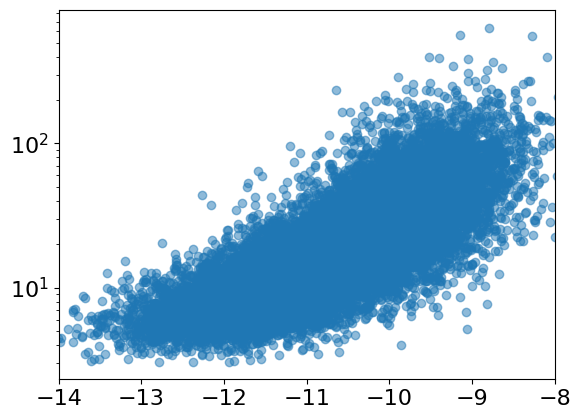

In [23]:
plt.scatter(dps_df_no_agn['LOGSFR']-dps_df_no_agn['LOGM'], dps_df_no_agn['Halpha_SNR'], alpha=0.5, color='C0')
plt.xlim(-14, -8)
plt.yscale('log')
plt.show()

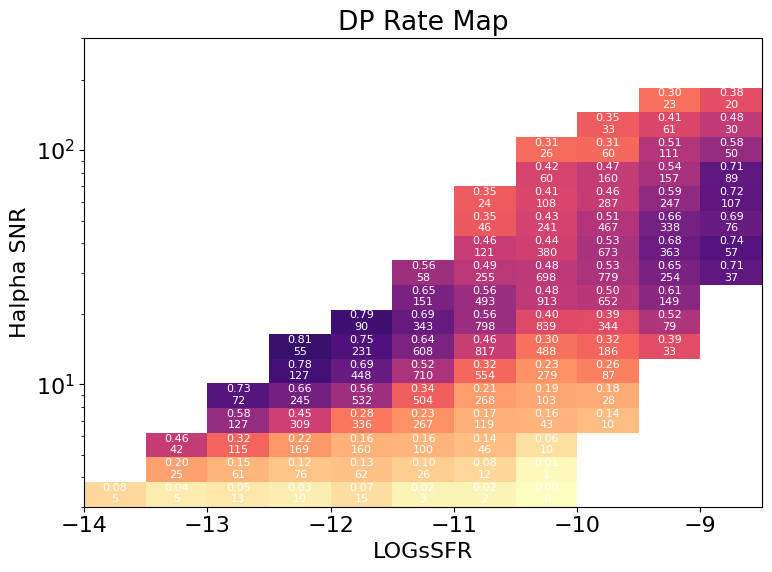

In [ ]:
H_all, _, _ = np.histogram2d(real_all_no_agn['LOGSFR']-real_all_no_agn['LOGM'], (real_all_no_agn['Halpha_SNR']), bins=[logssfr_bins_bound, snr_bins_bound])
H_dps, _, _ = np.histogram2d(dps_df_no_agn['LOGSFR']-dps_df_no_agn['LOGM'], (dps_df_no_agn['Halpha_SNR']), bins=[logssfr_bins_bound, snr_bins_bound])

# Avoid division by zero by replacing zeros in H_all with NaNs
with np.errstate(divide='ignore', invalid='ignore'):
    dp_rate_map = np.where(H_all<50, np.nan, H_dps / H_all)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# Use pcolormesh to plot the DP rate map
# Note: The histogram arrays need to be transposed for pcolormesh to match the axes
mesh = ax.pcolormesh(logssfr_bins_bound, snr_bins_bound, dp_rate_map.T, cmap='magma_r', vmin=0, vmax=1)

# Add text annotations for the rate in each bin
for i in range(len(logssfr_bins_bound) - 1):
    for j in range(len(snr_bins_bound) - 1):
        rate = dp_rate_map[i, j]
        if not np.isnan(rate):
            x_center = (logssfr_bins_bound[i] + logssfr_bins_bound[i+1]) / 2
            y_center = (snr_bins_bound[j] + snr_bins_bound[j+1]) / 2
            ax.text(x_center, y_center, f'{rate:.2f}\n{H_dps[i, j]:.0f}', 
                    ha='center', va='center', color='white', fontsize=8)

ax.set_xlabel('LOGsSFR')
ax.set_ylabel('Halpha SNR')
ax.set_title('DP Rate Map')
ax.set_xlim(logssfr_bins_bound[0], logssfr_bins_bound[-1])
ax.set_ylim(snr_bins_bound[0], snr_bins_bound[-1])
ax.set_yscale('log')
# fig.colorbar(mesh, ax=ax, label='DP Rate')
plt.tight_layout()
plt.show()

In [25]:
dps_df_no_agn['LOGSSFR'] = dps_df_no_agn['LOGSFR'] - dps_df_no_agn['LOGM']
dps_df_no_agn[(dps_df_no_agn['LOGSSFR']>-9) & ((dps_df_no_agn['Halpha_SNR']>20) & (dps_df_no_agn['Halpha_SNR']<80))].sort_values('LOGSSFR', ascending=True).head(30)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count,Halpha_LUM,OII_LUM,LOGSSFR
6256,39627764084511311,209.694000,-1.113934,0.192224,10.144199,1.144241,8.869574e+01,-95.698250,73.191681,66.218102,...,1,1,1,2,1.064013,1.144241,10,5.259065e+58,1.719479e+58,-8.999959
2183,39627746208384396,224.057114,-1.844011,0.355830,9.852580,0.854041,6.732670e+00,-14.835355,28.325218,75.741264,...,1,1,1,2,0.722971,0.854041,7,2.950297e+58,1.112801e+58,-8.998539
12055,39627788021403287,196.404175,-0.009543,0.123513,9.806411,0.808995,1.178322e+00,-3.432240,82.535286,26.398399,...,4,4,4,8,0.359385,0.808995,2,4.578544e+57,6.120677e+56,-8.997416
14238,39627794405134947,216.935104,0.305176,0.224253,9.982979,0.985772,8.959587e+01,-82.070129,55.240734,64.947342,...,1,1,1,2,0.959128,0.985772,9,2.739525e+58,4.071931e+57,-8.997206
169,39627739581384824,189.109619,-1.963263,0.334902,10.155889,1.158864,7.798462e+01,-21.048431,94.836876,108.926842,...,1,1,1,2,1.141777,1.158864,3,6.905467e+58,1.376043e+58,-8.997025
6751,39627769608409395,178.933350,-0.668285,0.136560,9.854947,0.859146,3.423744e+01,-46.435097,98.383705,24.766853,...,4,1,4,5,0.682771,0.859146,6,1.111824e+58,2.234324e+57,-8.995801
12170,39627788075927134,199.565720,-0.006689,0.082688,9.524340,0.530091,1.633435e+01,-11.250791,15.334589,51.980808,...,1,1,1,2,-0.335854,0.530091,9,2.206763e+57,5.101050e+56,-8.994249
8535,39627775732090954,183.837524,-0.555646,0.199588,9.706590,0.712562,1.412321e+01,-12.740778,70.726440,61.451187,...,1,1,1,2,0.403829,0.712562,2,1.448960e+58,5.997010e+57,-8.994027
16729,39627806258234648,203.309799,0.662047,0.172670,10.305641,1.311903,4.768347e-01,-6.708361,29.805418,64.603188,...,1,16,1,17,0.443886,1.311903,2,1.276788e+58,3.214856e+57,-8.993738
13161,39627793822125018,182.163864,0.155094,0.247911,10.040905,1.049473,8.588213e+00,-22.791451,78.069328,7.445209,...,1,1,1,2,0.892627,1.049473,2,1.961310e+58,1.450373e+57,-8.991432


In [26]:
dps_df_no_agn[((dps_df_no_agn['LOGSSFR']<-11.5) & (dps_df_no_agn['LOGSSFR']>-13)) & ((dps_df_no_agn['Halpha_SNR']>10) & (dps_df_no_agn['Halpha_SNR']<20))].sort_values('LOGSSFR', ascending=False).head(30)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count,Halpha_LUM,OII_LUM,LOGSSFR
1220,39627745671516488,192.236008,-1.659867,0.083817,9.766446,-1.733717,65.524239,-70.848587,38.713860,35.114197,...,1,1,1,2,-0.827410,-1.733717,2,8.670749e+56,1.767916e+56,-11.500163
18589,39627812482583875,214.393158,1.099681,0.201038,10.772583,-0.727704,23.779026,-6.904297,159.324402,44.642109,...,4,1,4,5,-0.351101,-0.727704,1,6.163861e+57,2.420393e+57,-11.500287
5196,39627763547640251,177.696335,-1.102672,0.186862,10.497831,-1.003073,84.372116,-114.026741,64.364136,67.250351,...,256,256,256,512,-0.159801,-1.003073,2,9.866085e+57,1.378503e+57,-11.500905
14433,39627794518379955,223.634888,0.227176,0.247979,10.526685,-0.974261,78.741432,-77.061829,41.762375,38.942547,...,256,256,256,512,0.023083,-0.974261,3,6.067097e+57,2.033851e+57,-11.500945
6185,39627764046760370,207.367279,-1.059947,0.126943,9.985620,-1.516347,35.478371,-69.311554,51.156483,17.407286,...,256,256,256,512,-0.743532,-1.516347,1,1.254770e+57,4.678526e+56,-11.501968
2577,39627751656785109,188.812042,-1.445095,0.248802,10.439981,-1.062251,97.264565,-103.933052,99.691704,55.977077,...,256,256,256,512,-0.195583,-1.062251,2,6.983869e+57,1.258555e+57,-11.502232
18197,39627812281259261,202.495575,0.927114,0.226485,10.143381,-1.359107,47.130558,-39.398529,31.096325,34.915565,...,256,256,256,512,-0.476799,-1.359107,1,3.025050e+57,2.002042e+56,-11.502488
9216,39627776071828786,204.061203,-0.512385,0.171703,10.358599,-1.144551,63.130161,-67.898209,51.015968,54.434074,...,256,256,256,512,-0.190576,-1.144551,2,4.084268e+57,6.424195e+56,-11.503150
15862,39627800566563276,224.021011,0.524492,0.138602,10.175797,-1.327391,33.467583,-111.929871,82.983513,28.484419,...,256,256,256,512,-0.865660,-1.327391,2,2.802504e+57,5.489562e+56,-11.503188
10881,39627782157767111,206.951782,-0.268538,0.101697,10.347487,-1.155867,20.921831,-38.697140,41.913452,155.373489,...,4,1,1,2,-0.618892,-1.155867,1,1.756381e+57,1.008563e+57,-11.503355
